In [ ]:
!pip install scikit-learn torch transformers

In [ ]:
!pip uninstall protobuf -y
!pip install protobuf==3.20.3

ERROR: Operation cancelled by user
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


In [3]:
import numpy as np
import pandas as pd
import re
from collections import Counter
import unicodedata
import shutil
import os
import json

In [4]:
df = pd.read_json("/content/drive/MyDrive/Colab Notebooks/NLP Project/data.json")

In [5]:
df.head(10)

,image_name,arxiv paper no.,page number,figure number,descriptions,text positions,caption_text,caption_positions
0,arXiv-2509.16951_p2_fig1_rasterized.png,arXiv-2509.16951,2,1,[This scheme employs 87Rb atoms as the physica...,"[[7766, 8196], [8526, 9646], [21890, 22502]]",FIG. 1: (a) Energy level structure diagram of ...,"[[8204, 8345]]"
1,arXiv-2509.16951_p2_fig2_rasterized.png,arXiv-2509.16951,2,2,"[state |e⟩≡|5P3/2, F = 3, mF = 3⟩and the Rydbe...","[[8526, 9646]]",FIG. 2: Schematic diagram of the structure of ...,"[[8345, 8526]]"
2,arXiv-2509.16951_p5_fig5_rasterized.png,arXiv-2509.16951,5,5,"[evolution time. According to (7) and (17), θ1...","[[16706, 17605]]",FIG. 5: The influence of Ω0(T −1) on fidelity ...,"[[17652, 17749]]"
3,arXiv-2509.16951_p5_fig3_rasterized.png,arXiv-2509.16951,5,3,"[where, ϑ = −π/3, Ω0 is the pulse amplitude, h...","[[16251, 16464], [16706, 17605]]",FIG. 3: The θ1(t) as a function of the time. T...,"[[16513, 16600]]"
4,arXiv-2509.16951_p5_fig6_rasterized.png,arXiv-2509.16951,5,6,"[As shown in Fig. 6, eΩ1(t) and eΩ2(t) of the ...","[[18270, 18670]]",FIG. 6: (a) Comparing the pulse Ω′ 1(t) and th...,"[[17791, 17947]]"
5,arXiv-2509.16951_p5_fig4_rasterized.png,arXiv-2509.16951,5,4,[],[],FIG. 4: The θ2(t) as a function of the time. T...,"[[16620, 16706]]"
6,arXiv-2509.16951_p6_fig7_rasterized.png,arXiv-2509.16951,6,7,"[As shown in Fig. 6, eΩ1(t) and eΩ2(t) of the ...","[[18270, 18670]]",FIG. 7: Under the three different conditions: ...,"[[18752, 18948]]"
7,arXiv-2509.16951_p6_fig8_rasterized.png,arXiv-2509.16951,6,8,[κf\nkb is the attenuation of photons in the k...,"[[19881, 20149]]",FIG. 8: The relationship between the fidelity ...,"[[20149, 20269]]"
8,arXiv-2509.16951_p7_fig9_rasterized.png,arXiv-2509.16951,7,9,"[in the cavity-fiber system. But in general, t...","[[20269, 21023]]",FIG. 9: (a)The fidelity versus δeΩ1 and δeΩ2. ...,"[[21755, 21835]]"
9,arXiv-2509.16951_p7_fig10_rasterized.png,arXiv-2509.16951,7,10,[Because the more the number of entangled qubi...,"[[21890, 22502]]",FIG. 10: A schematic diagram illustrating the ...,"[[23360, 23644]]"


In [6]:
df.shape

(17786, 8)

In [7]:
display(df.head(13000))

,image_name,arxiv paper no.,page number,figure number,descriptions,text positions,caption_text,caption_positions
0,arXiv-2509.16951_p2_fig1_rasterized.png,arXiv-2509.16951,2,1,[This scheme employs 87Rb atoms as the physica...,"[[7766, 8196], [8526, 9646], [21890, 22502]]",FIG. 1: (a) Energy level structure diagram of ...,"[[8204, 8345]]"
1,arXiv-2509.16951_p2_fig2_rasterized.png,arXiv-2509.16951,2,2,"[state |e⟩≡|5P3/2, F = 3, mF = 3⟩and the Rydbe...","[[8526, 9646]]",FIG. 2: Schematic diagram of the structure of ...,"[[8345, 8526]]"
2,arXiv-2509.16951_p5_fig5_rasterized.png,arXiv-2509.16951,5,5,"[evolution time. According to (7) and (17), θ1...","[[16706, 17605]]",FIG. 5: The influence of Ω0(T −1) on fidelity ...,"[[17652, 17749]]"
3,arXiv-2509.16951_p5_fig3_rasterized.png,arXiv-2509.16951,5,3,"[where, ϑ = −π/3, Ω0 is the pulse amplitude, h...","[[16251, 16464], [16706, 17605]]",FIG. 3: The θ1(t) as a function of the time. T...,"[[16513, 16600]]"
4,arXiv-2509.16951_p5_fig6_rasterized.png,arXiv-2509.16951,5,6,"[As shown in Fig. 6, eΩ1(t) and eΩ2(t) of the ...","[[18270, 18670]]",FIG. 6: (a) Comparing the pulse Ω′ 1(t) and th...,"[[17791, 17947]]"
...,...,...,...,...,...,...,...,...
12995,arXiv-2401.04892_p36_fig8_rasterized.png,arXiv-2401.04892,36,8,[is defined in(29). Figure 8 shows how A chang...,"[[48321, 48411], [48602, 48697], [48966, 49057]]",FIG. 8: Phase-Space Area occupeid by the photo...,"[[63905, 63985]]"
12996,arXiv-2401.04892_p37_fig9_rasterized.png,arXiv-2401.04892,37,9,[Figure 9 shows a measurement of the entanglem...,"[[51310, 51398], [51489, 51576], [51576, 51667...",FIG. 9: Linear Entropy (56) between matter and...,"[[64282, 64370]]"
12997,arXiv-2507.21688_p4_fig1_rasterized.png,arXiv-2507.21688,4,1,[Despite obvious similarities of Eqs. (8) and ...,"[[9495, 10990]]",FIG. 1. Comparison of standard and refined cel...,"[[14225, 14739]]"
12998,arXiv-2507.21688_p5_fig3_rasterized.png,arXiv-2507.21688,5,3,[The initial coherent state is centered at qi ...,"[[16497, 16897], [16897, 18388]]",FIG. 3. The chaotic quartic oscillator: Compar...,"[[20544, 21123]]"


In [8]:
missing_values = df.isnull().sum()
display(missing_values)

,0
image_name,0
arxiv paper no.,0
page number,0
figure number,0
descriptions,0
text positions,0
caption_text,0
caption_positions,0


In [9]:
empty_descriptions_count = df['descriptions'].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
print(f"Number of empty description lists: {empty_descriptions_count}")

Number of empty description lists: 1297


In [10]:
df['descriptions'].head()

,descriptions
0,[This scheme employs 87Rb atoms as the physica...
1,"[state |e⟩≡|5P3/2, F = 3, mF = 3⟩and the Rydbe..."
2,"[evolution time. According to (7) and (17), θ1..."
3,"[where, ϑ = −π/3, Ω0 is the pulse amplitude, h..."
4,"[As shown in Fig. 6, eΩ1(t) and eΩ2(t) of the ..."


In [11]:
df['descriptions'] = df['descriptions'].apply(
    lambda lst: " ".join(lst) if isinstance(lst, list) else lst
)


In [12]:
df['descriptions']

,descriptions
0,This scheme employs 87Rb atoms as the physical...
1,"state |e⟩≡|5P3/2, F = 3, mF = 3⟩and the Rydber..."
2,"evolution time. According to (7) and (17), θ1(..."
3,"where, ϑ = −π/3, Ω0 is the pulse amplitude, he..."
4,"As shown in Fig. 6, eΩ1(t) and eΩ2(t) of the f..."
...,...
17781,"(κ, χ) and N even in the parameter domains whe..."
17782,two-level Hamiltonian (14) can be constantly s...
17783,the limit was R = 0.\nTo explain this discrepa...
17784,two-level Hamiltonian (14) can be constantly s...


In [13]:
all_text = " ".join(df['descriptions'].dropna())
words = all_text.split()
from collections import Counter
word_counts = Counter(words)
word_counts.most_common(50)

[('the', 544306),
 ('of', 226949),
 ('in', 155350),
 ('and', 141183),
 ('a', 127538),
 ('to', 125208),
 ('is', 106680),
 ('for', 77793),
 ('=', 65411),
 ('with', 64161),
 ('The', 57942),
 ('that', 56181),
 ('we', 55246),
 ('as', 53000),
 ('Fig.', 52865),
 ('are', 43896),
 ('by', 43029),
 ('on', 33420),
 ('be', 32014),
 ('can', 30775),
 ('from', 30147),
 ('this', 28860),
 ('at', 28000),
 ('Figure', 26811),
 ('In', 26236),
 ('which', 25777),
 ('an', 22987),
 ('state', 22845),
 ('We', 21297),
 ('This', 19638),
 ('quantum', 18907),
 ('two', 18443),
 ('shown', 18048),
 ('between', 16483),
 ('where', 15822),
 ('it', 14280),
 ('not', 13906),
 ('.', 12890),
 ('each', 12865),
 ('1', 12632),
 ('our', 12473),
 ('time', 12431),
 ('For', 12217),
 ('states', 12211),
 ('one', 11634),
 ('all', 11454),
 ('number', 11275),
 ('also', 10846),
 ('using', 10284),
 ('have', 10216)]

In [14]:
df['caption_text'].apply(lambda text: text.lower())

,caption_text
0,fig. 1: (a) energy level structure diagram of ...
1,fig. 2: schematic diagram of the structure of ...
2,fig. 5: the influence of ω0(t −1) on fidelity ...
3,fig. 3: the θ1(t) as a function of the time. t...
4,fig. 6: (a) comparing the pulse ω′ 1(t) and th...
...,...
17781,fig. 10. components of the christoffel symbols...
17782,fig. 12. the two-level approximation of the me...
17783,fig. 11. an example of the geodesic flow for t...
17784,fig. 13. the geometry near the dp with l = 1 f...


In [15]:
df['descriptions'].apply(lambda text: text.lower())

,descriptions
0,this scheme employs 87rb atoms as the physical...
1,"state |e⟩≡|5p3/2, f = 3, mf = 3⟩and the rydber..."
2,"evolution time. according to (7) and (17), θ1(..."
3,"where, ϑ = −π/3, ω0 is the pulse amplitude, he..."
4,"as shown in fig. 6, eω1(t) and eω2(t) of the f..."
...,...
17781,"(κ, χ) and n even in the parameter domains whe..."
17782,two-level hamiltonian (14) can be constantly s...
17783,the limit was r = 0.\nto explain this discrepa...
17784,two-level hamiltonian (14) can be constantly s...


In [16]:
DOMAIN_STOPWORDS = { # not removed graphs, tables and equations
    "figure", "fig", "figs","figures",
    "section", "sec", "appendix",
    "shown", "shows", "show",
    "illustrate", "illustrates", "illustrated",
    "see"
}

In [17]:
def clean_text(text):
    # Unicode normalization
    text = unicodedata.normalize("NFKD", text)

    # Lowercase
    text = text.lower()

    # Keep only english letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # Tokenize
    tokens = text.split()

    # Remove domain-specific stopwords
    tokens = [t for t in tokens if t not in DOMAIN_STOPWORDS]

    # Rejoin
    return " ".join(tokens)


In [18]:
df['descriptions'] = df['descriptions'].astype(str).apply(clean_text)

In [19]:
df['caption_text'] = df['caption_text'].astype(str).apply(clean_text)

In [20]:
IMAGE_DIR = "/content/drive/MyDrive/Colab Notebooks/NLP Project/extracted_images"
OUTPUT_IMAGE_DIR = "/content/drive/MyDrive/Colab Notebooks/NLP Project/quantum_circuit_images"

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)

In [21]:
import re

# Pattern for quantum circuit mention
quantum_circuit_pattern = re.compile(
    r"\b(quantum circuits?|gates?)\b",
    flags=re.IGNORECASE
)

# Pattern for quantum gate symbols (isolated)
quantum_gates_pattern = re.compile(
    r"""
    (?<!\w)  # no letter/number before
    (
        # Standard single-qubit gates
        H|X|Y|Z|T|S|ID|SWAP|
        # Multi-qubit / controlled gates
        CNOT|CZ|CCX|Toffoli|
        # Parameterized gates (RX, RY, RZ, U1-U3) with optional control or Greek letters
        C?[α-ωA-Za-z]*R[XYZ]\s*\([^)]+\)|
        U[123]\s*\([^)]+\)|
        # Tensor products like H⊗X⊗RY(θ)
        (?:H|X|Y|Z|T|S|ID|SWAP|RX|RY|RZ|U[123]|CNOT|CZ|CCX|Toffoli)\s*(?:⊗\s*(?:H|X|Y|Z|T|S|ID|SWAP|RX|RY|RZ|U[123]|CNOT|CZ|CCX|Toffoli)\s*)+|
        # Optional indices/subscripts e.g., X1, CNOT_01
        (?:H|X|Y|Z|T|S|ID|SWAP|CNOT|CZ|CCX|Toffoli|RX|RY|RZ|U[123])[_\d]+
    )
    (?!\w)  # no letter/number after
    """,
    flags=re.IGNORECASE | re.VERBOSE
)

# Pattern for words to exclude
negative_pattern = re.compile(
    r"\b(graphs?|tables?|equations?|plots?)\b",
    flags=re.IGNORECASE
)

# ----------------------------------------------------
# Apply filtering
# ----------------------------------------------------

filtered_df = df[
    (
        df["caption_text"].str.contains(quantum_circuit_pattern, na=False)
        # |
        # df["caption_text"].str.contains(quantum_gates_pattern, na=False)
        # |
        # df["descriptions"].str.contains(quantum_gates_pattern, na=False)
    )
    &
    ~(
        df["caption_text"].str.contains(negative_pattern, na=False)
        |
        df["descriptions"].str.contains(negative_pattern, na=False)
    )
].copy()

print(f"Found {len(filtered_df)} high-confidence quantum circuit rows")



/tmp/ipython-input-3117097029.py:43: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["caption_text"].str.contains(quantum_circuit_pattern, na=False)
/tmp/ipython-input-3117097029.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["caption_text"].str.contains(negative_pattern, na=False)
/tmp/ipython-input-3117097029.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["descriptions"].str.contains(negative_pattern, na=False)


Found 1146 high-confidence quantum circuit rows


In [ ]:
missing_images = []

for img_name in filtered_df["image_name"]:
    src_path = os.path.join(IMAGE_DIR, img_name)
    dst_path = os.path.join(OUTPUT_IMAGE_DIR, img_name)

    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)   # copy2 preserves metadata
    else:
        missing_images.append(img_name)

print(f"Copied images to: {OUTPUT_IMAGE_DIR}")

if missing_images:
    print("\nWarning: Some images were missing:")
    for m in missing_images:
        print(" -", m)

In [22]:
image_files = []
with open("/content/drive/MyDrive/Colab Notebooks/NLP Project/image_files.json",'r') as f:
    image_files = set(json.load(f))

In [23]:
def combine_description_and_caption(row):
    desc_list = row["descriptions"]
    caption = row["caption_text"]

    parts = []

    # Handle description list
    if isinstance(desc_list, list):
        parts.extend([str(d) for d in desc_list if pd.notna(d)])

    # Handle caption text
    if pd.notna(caption):
        parts.append(str(caption))

    return " ".join(parts)

df["final_description"] = df.apply(combine_description_and_caption, axis=1)

In [24]:
remove_pattern = re.compile(
    r"\bquantum circuits?\b|\bgates?\b",
    flags=re.IGNORECASE
)

def clean_description(desc_list):
    if not isinstance(desc_list, list):
        return desc_list

    cleaned = []
    for text in desc_list:
        if isinstance(text, str):
            cleaned_text = remove_pattern.sub("", text)
            # normalize extra spaces
            cleaned_text = re.sub(r"\s{2,}", " ", cleaned_text).strip()
            cleaned.append(cleaned_text)
        else:
            cleaned.append(text)

    return cleaned

df["final_description"] = df["final_description"].apply(clean_description)


In [25]:
df["final_description"]

,final_description
0,a energy level structure diagram of a single r...
1,schematic diagram of the structure of the rydb...
2,the influence of t on fidelity f t when t the ...
3,the t as a function of the time the parameters...
4,a comparing the pulse t and the fitting of gau...
...,...
17781,components of the christoffel symbols n for ha...
17782,the two level approximation of the metric tens...
17783,an example of the geodesic flow for the model ...
17784,the geometry near the dp with l for the model ...


In [26]:
positive_df = df[df['image_name'].isin(image_files)]

In [27]:
positive_df

,image_name,arxiv paper no.,page number,figure number,descriptions,text positions,caption_text,caption_positions,final_description
12,arXiv-2412.04421_p3_fig3_rasterized.png,arXiv-2412.04421,3,3,pulses are generated by an arbitrary waveform ...,"[[8319, 10231], [11367, 12586], [12586, 13352]...",pulse amplitude calibration drift and fluc tua...,"[[10443, 11367]]",pulse amplitude calibration drift and fluc tua...
77,arXiv-2502.01398_p30_fig25_rasterized.png,arXiv-2502.01398,30,25,only be or the function s output f x can also ...,"[[146518, 147410]]",quantum circuit implementing deutsch s algorit...,"[[146275, 146518]]",quantum circuit implementing deutsch s algorit...
86,arXiv-2510.13541_p10_fig8_rasterized.png,arXiv-2510.13541,10,8,bell measurements are joint measurements on tw...,"[[45921, 46524], [46976, 48164]]",bell measurement circuits and their representa...,"[[46524, 46976]]",bell measurement circuits and their representa...
88,arXiv-2510.13541_p12_fig10_rasterized.png,arXiv-2510.13541,12,10,the results from simulations identifying the t...,"[[51306, 52730]]",data from threshold simulations a the benchmar...,"[[53488, 53977]]",data from threshold simulations a the benchmar...
94,arXiv-2408.06561_p3_fig1_rasterized.png,arXiv-2408.06561,3,1,,[],one typical implementation of a one bit full a...,"[[10285, 10614]]",one typical implementation of a one bit full a...
...,...,...,...,...,...,...,...,...,...
17630,arXiv-2509.11861_p6_fig4_rasterized.png,arXiv-2509.11861,6,4,hilbert schmidt decomposition across a biparti...,"[[16503, 18526]]",applying a two mode unitary gate in layer d vl...,"[[18783, 19296]]",applying a two mode unitary gate in layer d vl...
17634,arXiv-2509.11861_p20_fig8_rasterized.png,arXiv-2509.11861,20,8,we present the results of a d planar field sim...,"[[72512, 73004], [73004, 74371]]",results of d lp field simulations of one nonli...,"[[75152, 75482]]",results of d lp field simulations of one nonli...
17635,arXiv-2509.11861_p21_fig9_rasterized.png,arXiv-2509.11861,21,9,as explained above for the d case the circuit ...,"[[79024, 80735]]",the propagation of a pulse through a swap gate...,"[[77656, 78336]]",the propagation of a pulse through a swap gate...
17637,arXiv-2509.11861_p24_fig11_rasterized.png,arXiv-2509.11861,24,11,is negligible e g ref in we present the result...,"[[85826, 86107], [86107, 86554], [86554, 87755...",the gaussian comparison for sensing for l wave...,"[[87758, 88465]]",the gaussian comparison for sensing for l wave...


In [28]:
positive_df['label']=1

/tmp/ipython-input-1492758434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_df['label']=1


In [29]:
# Remove rows whose image_name is in image_list
candidate_negatives = df[~df["image_name"].isin(image_files)]

# Randomly sample 500 rows from the remaining data
negative_df = candidate_negatives.sample(n=1200, random_state=42).copy()

# Add label column
negative_df["label"] = 0


In [31]:
os.makedirs("/content/drive/MyDrive/Colab Notebooks/NLP Project/negative_df_images", exist_ok=True)
for img_name in negative_df["image_name"]:
    src_path = os.path.join(IMAGE_DIR, img_name)
    dst_path = os.path.join("/content/drive/MyDrive/Colab Notebooks/NLP Project/negative_df_images", img_name)

    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)   # copy2 preserves metadata
    else:
        missing_images.append(img_name)

print(f"Copied images to: {OUTPUT_IMAGE_DIR}")

if missing_images:
    print("\nWarning: Some images were missing:")
    for m in missing_images:
        print(" -", m)

Copied images to: /content/drive/MyDrive/Colab Notebooks/NLP Project/quantum_circuit_images


NameError: name 'missing_images' is not defined

In [30]:
labeled_df = pd.concat([positive_df, negative_df], ignore_index=True)

In [31]:
# Get the set of image names already in labeled_df
used_images = set(labeled_df['image_name'])

# Filter df to exclude these image_names
remaining_df = df[~df['image_name'].isin(used_images)]

# Sample 4000 random rows
unlabeled_df = remaining_df.sample(n=8000, random_state=42).copy()


In [32]:
unlabeled_texts = unlabeled_df['final_description'].tolist()

In [33]:
from sklearn.model_selection import train_test_split

# First split: train (70%) and temp (30%)
main_df, test_df = train_test_split(labeled_df, test_size=0.2, random_state=42, stratify=labeled_df['label'])

print(f"Train: {len(main_df)}, Test: {len(test_df)}")


Train: 1879, Test: 470


In [34]:
main_texts = main_df['final_description'].to_list()
main_labels = main_df['label'].to_list()

In [35]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

In [36]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.2,       # dropout in feed-forward layers
    attention_probs_dropout_prob=0.2  # dropout in attention layers
)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
optimizer = AdamW(model.parameters(), lr=2e-5,weight_decay=0.01)
device = "cuda"
start_epoch = 0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
checkpoint_path = Path("/content/drive/MyDrive/Colab Notebooks/NLP Project/checkpoint.pt")

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)
    start_epoch = checkpoint["epoch"] + 1


In [37]:
class TextDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = texts
        self.labels = labels  # can be None for unlabeled
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        item = {"text": self.texts[idx]}
        if self.labels is not None:
            item["label"] = self.labels[idx]
        return item

In [38]:
def collate_fn(batch, tokenizer, num_classes, max_len=128):
    texts = [b["text"] for b in batch]
    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

    # Check if ANY item in the batch has a label, not just the first one
    if any("label" in b for b in batch):
        labels = []
        for b in batch:
            if "label" in b:
                if isinstance(b["label"], torch.Tensor):
                    # Soft pseudo-label (already a tensor)
                    labels.append(b["label"])
                else:
                    # Hard label (integer) -> convert to one-hot
                    one_hot = torch.zeros(num_classes)
                    one_hot[b["label"]] = 1.0
                    labels.append(one_hot)
            else:
                 # Handle missing label in a mixed batch (e.g., use zeros or ignore)
                 # For semi-supervised, usually we prefer separate loaders, but if mixed:
                 labels.append(torch.zeros(num_classes))

        labels = torch.stack(labels)
        return enc, labels

    return enc

In [39]:
def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = torch.tensor(np.random.beta(0.4, 0.4), device=device, dtype=torch.float32)  # ✅ Explicitly on GPU
    else:
        lam = 1
    batch_size = x["input_ids"].size(0)
    index = torch.randperm(batch_size)
    mixed_x = {}
    for k in x:
        mixed_x[k] = lam * x[k] + (1 - lam) * x[k][index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def soft_cross_entropy(pred, soft_targets):
    log_probs = F.log_softmax(pred, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()

In [40]:
def save_checkpoint(path, model, optimizer, epoch):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict()
    }, path)

In [41]:
def warmup_training(model, tokenizer, optimizer, labeled_texts, labeled_labels,
                       unlabeled_texts, epochs=10, warmup_epochs=1,
                       batch_size=16, confidence_threshold=0.6, lr=2e-5, val_split=0.2, device="cuda"):
  model.to(device)

  # Split labeled data into train/val
  train_texts, val_texts, train_labels, val_labels = train_test_split(
      labeled_texts, labeled_labels, test_size=val_split, random_state=42
  )

  train_labels_tensor = torch.tensor(train_labels,dtype=torch.long)
  val_labels_tensor = torch.tensor(val_labels,dtype=torch.long)

  train_dataset = TextDataset(train_texts, train_labels_tensor)
  val_dataset = TextDataset(val_texts, val_labels_tensor)
  unlabeled_dataset = TextDataset(unlabeled_texts)

  # Warm-up on labeled train data
  warmup_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              collate_fn=lambda b: collate_fn(b, tokenizer, model.num_labels))
  model.train()
  for _ in range(warmup_epochs):
      for enc, labels in tqdm(warmup_loader, desc="Warm-up batches"):
          enc = {k:v.to(device) for k,v in enc.items()}
          labels = F.one_hot(labels.to(device), num_classes=model.num_labels).float()
          optimizer.zero_grad()
          outputs = model(**enc).logits
          loss = F.cross_entropy(outputs, labels)
          loss.backward()
          optimizer.step()

  return model


In [42]:
from tqdm.auto import tqdm
from itertools import cycle
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
from tqdm.auto import tqdm
from itertools import cycle

def pseudo_label_train(model, tokenizer, optimizer, labeled_texts, labeled_labels,
                       unlabeled_texts, epochs=10, warmup_epochs=1,
                       batch_size=16, min_labeled_per_batch=4,
                       positive_threshold=0.85, negative_threshold=0.65, lr=2e-5, val_split=0.2, device="cuda"):

    model.to(device)

    # Split labeled data into train/val
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        labeled_texts, labeled_labels, test_size=val_split, random_state=42
    )

    train_labels_tensor = torch.tensor(train_labels,dtype=torch.long)
    val_labels_tensor = torch.tensor(val_labels,dtype=torch.long)

    train_dataset = TextDataset(train_texts, train_labels_tensor)
    val_dataset = TextDataset(val_texts, val_labels_tensor)
    unlabeled_dataset = TextDataset(unlabeled_texts)

    # Warm-up on labeled train data
    # warmup_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
    #                            collate_fn=lambda b: collate_fn(b, tokenizer, model.num_labels))
    model.train()

    # Main pseudo-labeling loop
    for epoch in tqdm(range(epochs), desc="Epochs"):
        # ------------------------
        # Generate soft pseudo-labels for unlabeled data
        # ------------------------
        try:
          tqdm.write(f"\nEpoch {epoch+1}/{epochs}")
          unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=batch_size,
                                        shuffle=False, collate_fn=lambda b: collate_fn(b, tokenizer, model.num_labels))
          model.eval()
          pseudo_labels = []
          selected_unlabeled_texts = []

          with torch.no_grad():
              for enc in tqdm(unlabeled_loader, desc="Generating pseudo-labels", leave=False):
                  # print("HERE 0")
                  enc = {k:v.to(device) for k,v in enc.items()}
                  outputs = F.softmax(model(**enc).logits, dim=1)
                  # print("HERE 00")
                  prob_class_1 = outputs[:, 1]
                  high_conf_class_1 = prob_class_1 >= positive_threshold

                  prob_class_0 = outputs[:, 0]
                  high_conf_class_0 = (prob_class_0 >= negative_threshold) & (~high_conf_class_1)

                  mask = high_conf_class_1 | high_conf_class_0
                  if mask.sum() > 0:
                      pseudo_labels.append(outputs[mask])
                      selected_unlabeled_texts.extend([unlabeled_dataset.texts[i] for i, m in enumerate(mask) if m])
          # print("HERE1")
          if pseudo_labels:
            pseudo_labels = torch.cat(pseudo_labels, dim=0)

            # 🔍 ADD THESE LINES:
            num_pseudo_labeled = len(selected_unlabeled_texts)
            total_unlabeled = len(unlabeled_dataset)
            percentage = (num_pseudo_labeled / total_unlabeled) * 100

            tqdm.write(f"📊 Pseudo-labeling Stats (Epoch {epoch+1}):")
            tqdm.write(f"   - Total unlabeled: {total_unlabeled}")
            tqdm.write(f"   - High-confidence samples: {num_pseudo_labeled}")
            tqdm.write(f"   - Percentage selected: {percentage:.2f}%")
          else:
            pseudo_labels = torch.zeros((0, model.num_labels)).to(device)
            selected_unlabeled_texts = []

            # 🔍 ADD THIS LINE:
            tqdm.write(f"⚠️ No samples exceeded any confidence threshold ")

          # ------------------------
          # Combine labeled + selected pseudo-labeled data
          # ------------------------
          # print("HERE2")
                    # ------------------------
          # GUARANTEED BATCH RATIO LOGIC
          # ------------------------

          # Only proceed with dual-loading if we actually have pseudo-labeled data
          if len(selected_unlabeled_texts) > 0:

              # 1. Create Datasets
              # Labeled dataset already exists as 'train_dataset'
              # Create a fresh dataset for the newly selected pseudo-labels
              pseudo_dataset = TextDataset(selected_unlabeled_texts, pseudo_labels)

              # 2. Define Batch Sizes
              # Ensure we don't ask for more labeled samples than exist in the dataset
              n_labeled = min(min_labeled_per_batch, batch_size)
              n_pseudo = batch_size - n_labeled

              # 3. Create Separate Loaders
              # Labeled Loader: Shuffled, drops last to avoid small batches messing up ratio
              max_len = 128
              labeled_loader = DataLoader(
                train_dataset,
                batch_size=n_labeled,
                shuffle=True,
                drop_last=True,
                collate_fn=lambda b: collate_fn(b, tokenizer, model.num_labels, max_len=max_len)
            )
            # Pseudo Loader
              pseudo_loader = DataLoader(
                pseudo_dataset,
                batch_size=n_pseudo,
                shuffle=True,
                drop_last=True,
                collate_fn=lambda b: collate_fn(b, tokenizer, model.num_labels, max_len=max_len)
            )

              # 4. Training Loop (Zipping ensures strict ratio)
              model.train()
              # We cycle the labeled loader in case it's smaller than the pseudo loader
              # (so we don't stop training early just because we ran out of unique labeled batches)

              # If labeled set is huge and pseudo is small, we iterate pseudo.
              # Usually pseudo is larger. We'll zip against the shorter one or cycle.
              # Safer strategy: Zip and stop when shortest runs out (usually labeled).
              # To extend: zip(cycle(labeled_loader), pseudo_loader)

              combined_iterator = zip(cycle(labeled_loader), pseudo_loader)
              # Estimate steps for progress bar based on pseudo_loader (usually larger)
              total_steps = len(pseudo_loader)

              progress_bar = tqdm(combined_iterator, total=total_steps, desc="Training batches", leave=False)

              for (enc_l, labels_l), (enc_p, labels_p) in progress_bar:

                  # --- Combine Inputs ---
                  # Move dicts to device
                  enc_l = {k: v.to(device) for k, v in enc_l.items()}
                  enc_p = {k: v.to(device) for k, v in enc_p.items()}
                  # ✅ FIX: Ensure both batches have same sequence length for ALL keys
                  max_seq_len = max(enc_l['input_ids'].size(1), enc_p['input_ids'].size(1))
                  # Pad enc_l if needed
                  if enc_l['input_ids'].size(1) < max_seq_len:
                      padding_size = max_seq_len - enc_l['input_ids'].size(1)
                      for key in enc_l.keys():
                          if key == 'input_ids':
                              enc_l[key] = F.pad(enc_l[key], (0, padding_size), value=tokenizer.pad_token_id)
                          elif key == 'attention_mask':
                              enc_l[key] = F.pad(enc_l[key], (0, padding_size), value=0)
                          elif key == 'token_type_ids':
                              enc_l[key] = F.pad(enc_l[key], (0, padding_size), value=0)
                    # Pad enc_p if needed
                  if enc_p['input_ids'].size(1) < max_seq_len:
                        padding_size = max_seq_len - enc_p['input_ids'].size(1)
                        for key in enc_p.keys():
                            if key == 'input_ids':
                                enc_p[key] = F.pad(enc_p[key], (0, padding_size), value=tokenizer.pad_token_id)
                            elif key == 'attention_mask':
                                enc_p[key] = F.pad(enc_p[key], (0, padding_size), value=0)
                            elif key == 'token_type_ids':
                                enc_p[key] = F.pad(enc_p[key], (0, padding_size), value=0)
                    # Concatenate tensors in the dict (input_ids, attention_mask, etc.)
                  enc_combined = {}
                  for key in enc_l:
                      enc_combined[key] = torch.cat([enc_l[key], enc_p[key]], dim=0)

                  # --- Combine Labels ---
                  # Format Labeled (Ground Truth): Convert indices to One-Hot if needed
                  if labels_l.ndim == 1 or labels_l.shape[-1] != model.num_labels:
                      labels_l = F.one_hot(labels_l.to(device).long(), num_classes=model.num_labels).float()
                  else:
                      labels_l = labels_l.to(device).float()

                  # Format Pseudo: Already soft tensor, just move to device
                  labels_p = labels_p.to(device).float()

                  labels_combined = torch.cat([labels_l, labels_p], dim=0)

                  # --- Train Step (Mixup) ---
                  # --- Train Step (Mixup) ---
                  # Fix: Mix embeddings instead of input_ids
                  input_ids = enc_combined["input_ids"].to(device)
                  attention_mask = enc_combined["attention_mask"].to(device)

                  inputs_embeds = model.bert.embeddings(input_ids)

                  batch_size = input_ids.size(0)
                  index = torch.randperm(batch_size).to(device)
                  if 0.4 > 0:
                      lam = np.random.beta(0.4, 0.4)
                  else:
                      lam = 1

                  mixed_embeds = lam * inputs_embeds + (1 - lam) * inputs_embeds[index]
                  mixed_mask = torch.max(attention_mask, attention_mask[index])

                  y_a, y_b = labels_combined, labels_combined[index]

                  optimizer.zero_grad()
                  outputs = model(inputs_embeds=mixed_embeds, attention_mask=mixed_mask).logits
                  loss = lam * soft_cross_entropy(outputs, y_a) + (1-lam) * soft_cross_entropy(outputs, y_b)

                  loss.backward()
                  optimizer.step()

          else:
              # Fallback: No pseudo-labels generated this epoch (early training or high threshold)
              # Just train on labeled data normally
              tqdm.write("No pseudo-labels generated. Training on labeled data only.")
              labeled_loader = DataLoader(
                  train_dataset,
                  batch_size=batch_size,
                  shuffle=True,
                  collate_fn=lambda b: collate_fn(b, tokenizer, model.num_labels)
              )

              model.train()
              for enc, labels in tqdm(labeled_loader, desc="Training (Labeled Only)", leave=False):
                  enc = {k: v.to(device) for k, v in enc.items()}
                  labels_l = labels.to(device).long()

                  # One-hot
                  labels_oh = F.one_hot(labels_l, num_classes=model.num_labels).float()

                  # Mixup (optional here, but consistent)
                  # Mixup (optional here, but consistent)
                  input_ids = enc["input_ids"].to(device)
                  attention_mask = enc["attention_mask"].to(device)
                  inputs_embeds = model.bert.embeddings(input_ids)

                  batch_size = input_ids.size(0)
                  index = torch.randperm(batch_size).to(device)
                  if 0.4 > 0:
                      lam = np.random.beta(0.4, 0.4)
                  else:
                      lam = 1

                  mixed_embeds = lam * inputs_embeds + (1 - lam) * inputs_embeds[index]
                  mixed_mask = torch.max(attention_mask, attention_mask[index])

                  y_a, y_b = labels_oh, labels_oh[index]

                  optimizer.zero_grad()
                  outputs = model(inputs_embeds=mixed_embeds, attention_mask=mixed_mask).logits
                  loss = lam * soft_cross_entropy(outputs, y_a) + (1-lam) * soft_cross_entropy(outputs, y_b)
                  loss.backward()
                  optimizer.step()

          # ------------------------
          # Validation
          # ------------------------
          val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                                  collate_fn=lambda b: collate_fn(b, tokenizer, model.num_labels))
          model.eval()
          val_loss = 0.0
          total = 0
          all_preds = []
          all_labels = []

          with torch.no_grad():
            for enc, labels in tqdm(val_loader, desc="Validation batches", leave=False):
                enc = {k: v.to(device) for k, v in enc.items()}
                labels = labels.to(device)

                # Forward
                outputs = model(**enc).logits

                # Loss (use CE, NOT soft CE)
                loss = F.cross_entropy(outputs, labels)
                val_loss += loss.item() * labels.size(0)
                total += labels.size(0)

                # Predictions
                probs = F.softmax(outputs, dim=1)[:, 1]
                preds = (probs > 0.7).int()   # tune this   

                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

          val_loss /= total
          all_preds = torch.cat(all_preds)
          all_labels = torch.cat(all_labels)

          val_precision = precision_score(all_labels, all_preds, pos_label=1)
          val_recall = recall_score(all_labels, all_preds, pos_label=1)
          val_f1 = f1_score(all_labels, all_preds, pos_label=1)
          val_acc = (all_preds == all_labels).float().mean().item()

          tqdm.write(
            f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f}, "
            f"Precision={val_precision:.4f}, Recall={val_recall:.4f}, F1={val_f1:.4f}"
          )


        except Exception as e:
          print("❌ Crash detected — saving checkpoint")
          save_checkpoint("/kaggle/working/checkpoint.pt", model, optimizer, epoch)
          raise e

    return model, pseudo_labels.cpu().numpy()


In [45]:
model = warmup_training(model, tokenizer, optimizer, main_texts, main_labels,
                       unlabeled_texts, warmup_epochs=3)

Warm-up batches:   0%|          | 0/94 [00:00<?, ?it/s]

Warm-up batches:   0%|          | 0/94 [00:00<?, ?it/s]

Warm-up batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [46]:
trained_model, pseudo_labels_array = pseudo_label_train(model, tokenizer, optimizer, main_texts, main_labels,
                       unlabeled_texts, epochs=10, warmup_epochs=10,
                       batch_size=16, min_labeled_per_batch=4,
                       positive_threshold=0.95, negative_threshold =0.80, lr=2e-5, val_split=0.2, device="cuda")

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]


Epoch 1/10


Generating pseudo-labels:   0%|          | 0/500 [00:00<?, ?it/s]

📊 Pseudo-labeling Stats (Epoch 1):
   - Total unlabeled: 8000
   - High-confidence samples: 7878
   - Percentage selected: 98.47%


Training batches:   0%|          | 0/656 [00:00<?, ?it/s]

...

Training batches:   0%|          | 0/620 [00:00<?, ?it/s]

Validation batches:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 5: Val Loss=0.1701, Acc=0.9574, Precision=0.6667, Recall=1.0000, F1=0.8000

Epoch 6/10


Generating pseudo-labels:   0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [47]:
save_checkpoint("/content/drive/MyDrive/Colab Notebooks/NLP Project/checkpoint.pt", trained_model, optimizer, 10)

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
def evaluate_model(model, tokenizer, test_texts, test_labels, batch_size=16, device="cuda"):
    """
    Evaluate model on test dataset and return comprehensive metrics

    Args:
        model: Trained BERT model
        tokenizer: BERT tokenizer
        test_texts: List of test texts
        test_labels: List of test labels
        batch_size: Batch size for evaluation
        device: Device to run on (cuda/cpu)

    Returns:
        dict: Dictionary containing all metrics
    """
    model.to(device)
    model.eval()

    # Create test dataset and loader
    test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)
    test_dataset = TextDataset(test_texts, test_labels_tensor)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: collate_fn(b, tokenizer, model.num_labels)
    )

    all_predictions = []
    all_probabilities = []
    all_true_labels = []

    print("Running predictions on test set...")
    with torch.no_grad():
        for enc, labels in test_loader:
            # Move to device
            enc = {k: v.to(device) for k, v in enc.items()}

            # Get predictions
            outputs = model(**enc).logits
            probabilities = F.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)

            # Store results
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_true_labels.extend(labels.numpy())

    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_probabilities = np.array(all_probabilities)
    all_true_labels = np.array(all_true_labels)

    # Calculate metrics
    accuracy = accuracy_score(all_true_labels, all_predictions)
    precision, recall, f1, support = precision_recall_fscore_support(
        all_true_labels,
        all_predictions,
        average='binary'
    )

    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        all_true_labels,
        all_predictions,
        average=None,
        labels=[0, 1]
    )

    # Confusion matrix
    cm = confusion_matrix(all_true_labels, all_predictions)

    # ROC AUC (using probability of positive class)
    roc_auc = roc_auc_score(all_true_labels, all_probabilities[:, 1])

    # Organize results
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'per_class_metrics': {
            'class_0': {
                'precision': precision_per_class[0],
                'recall': recall_per_class[0],
                'f1_score': f1_per_class[0],
                'support': support_per_class[0]
            },
            'class_1': {
                'precision': precision_per_class[1],
                'recall': recall_per_class[1],
                'f1_score': f1_per_class[1],
                'support': support_per_class[1]
            }
        },
        'predictions': all_predictions,
        'probabilities': all_probabilities,
        'true_labels': all_true_labels
    }

    return results


In [50]:
def print_metrics(results):
    """Print formatted metrics"""
    print("\n" + "="*60)
    print("MODEL EVALUATION RESULTS")
    print("="*60)

    print(f"\n📊 Overall Metrics:")
    print(f"  Accuracy:  {results['accuracy']:.4f}")
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  Recall:    {results['recall']:.4f}")
    print(f"  F1-Score:  {results['f1_score']:.4f}")
    print(f"  ROC-AUC:   {results['roc_auc']:.4f}")

    print(f"\n📈 Per-Class Metrics:")
    for class_name, metrics in results['per_class_metrics'].items():
        print(f"\n  {class_name.upper()}:")
        print(f"    Precision: {metrics['precision']:.4f}")
        print(f"    Recall:    {metrics['recall']:.4f}")
        print(f"    F1-Score:  {metrics['f1_score']:.4f}")
        print(f"    Support:   {metrics['support']:.0f} samples")

    print("\n" + "="*60)
def plot_confusion_matrix(cm, class_names=['Non-Quantum', 'Quantum Circuit']):
    """Plot confusion matrix as heatmap"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
def plot_roc_curve(true_labels, probabilities):
    """Plot ROC curve"""
    fpr, tpr, thresholds = roc_curve(true_labels, probabilities[:, 1])
    roc_auc = roc_auc_score(true_labels, probabilities[:, 1])

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve',
              fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
def plot_class_distribution(true_labels, predictions):
    """Plot distribution comparison"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # True distribution
    unique, counts = np.unique(true_labels, return_counts=True)
    ax1.bar(['Non-Quantum', 'Quantum Circuit'], counts, color=['#1f77b4', '#ff7f0e'])
    ax1.set_title('True Label Distribution', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12)
    for i, v in enumerate(counts):
        ax1.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

    # Predicted distribution
    unique, counts = np.unique(predictions, return_counts=True)
    ax2.bar(['Non-Quantum', 'Quantum Circuit'], counts, color=['#1f77b4', '#ff7f0e'])
    ax2.set_title('Predicted Label Distribution', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12)
    for i, v in enumerate(counts):
        ax2.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [51]:
test_texts = test_df['final_description'].tolist()
test_labels = test_df['label'].tolist()
# Evaluate model
results = evaluate_model(
    model=model,  # or just 'model' if you haven't renamed it
    tokenizer=tokenizer,
    test_texts=test_texts,
    test_labels=test_labels,
    batch_size=16,
    device="cuda"
)

Running predictions on test set...



MODEL EVALUATION RESULTS

📊 Overall Metrics:
  Accuracy:  0.9489
  Precision: 0.9256
  Recall:    0.9739
  F1-Score:  0.9492
  ROC-AUC:   0.9694

📈 Per-Class Metrics:

  CLASS_0:
    Precision: 0.9737
    Recall:    0.9250
    F1-Score:  0.9487
    Support:   240 samples

  CLASS_1:
    Precision: 0.9256
    Recall:    0.9739
    F1-Score:  0.9492
    Support:   230 samples



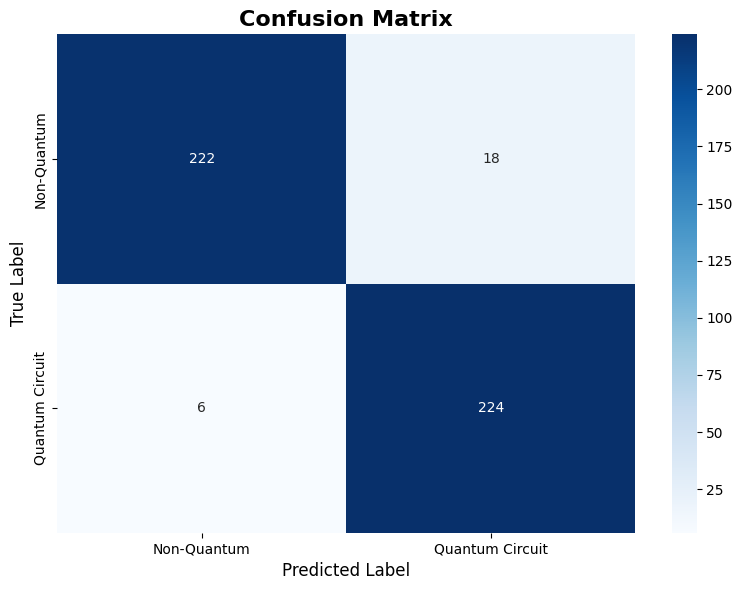

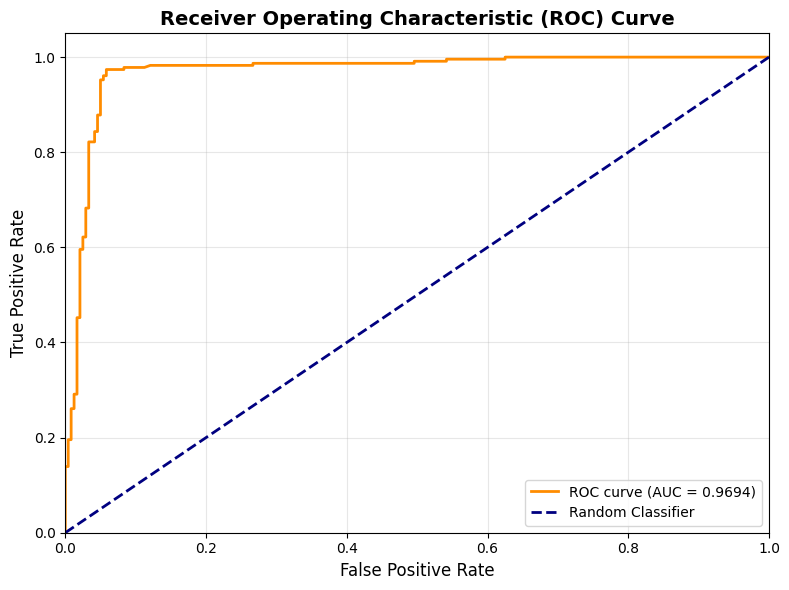

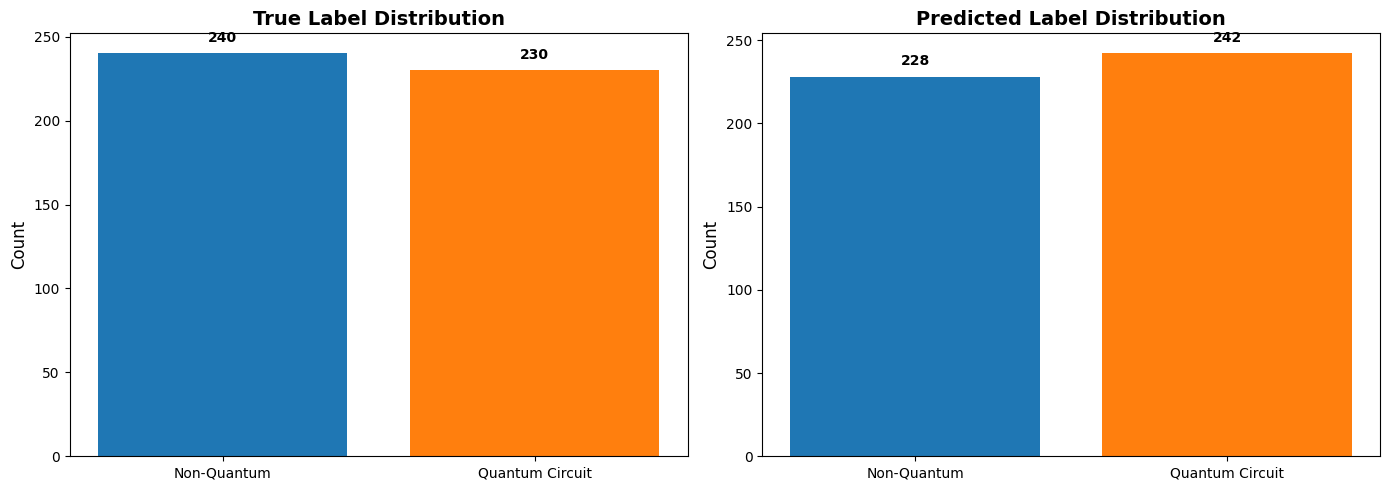

In [52]:
print_metrics(results)
# Plot visualizations
plot_confusion_matrix(results['confusion_matrix'])
plot_roc_curve(results['true_labels'], results['probabilities'])
plot_class_distribution(results['true_labels'], results['predictions'])

In [ ]:
save_checkpoint("/kaggle/working/checkpoint.pt", model, optimizer, 4)